<a href="https://colab.research.google.com/github/abdullaawad/Data-Warehousing-Coursework/blob/main/DWCoursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Install Package
!pip install yfinance
!pip install yahoofinancials


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 790.0 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=5df5afbf73ae8328967b3f3086e8422d385368a64ea6a956a439d74e5d62b787
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [3]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
from IPython.display import display
import yfinance as yf
from yahoofinancials import YahooFinancials
from datetime import datetime
from typing import dataclass_transform
import numpy as np

In [4]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

In [5]:
response = requests.get(url, headers=headers)
response.raise_for_status()

# Read all tables on the page
tables = pd.read_html(StringIO(response.text))

# Find the table that contains a 'Symbol' column
sp500_table = None
for table in tables:
    cols_lower = [str(c).lower() for c in table.columns]
    if "symbol" in cols_lower:
        sp500_table = table.copy()
        break

if sp500_table is None:
    raise ValueError("No table with a 'Symbol' column found on the page.")

# Standardise column name to 'Symbol'
for col in sp500_table.columns:
    if str(col).lower() == "symbol":
        symbol_col = col
        break

sp500_table.rename(columns={symbol_col: "Symbol"}, inplace=True)

# Clean tickers (BRK.B → BRK-B) for Yahoo Finance
sp500_table["Symbol"] = (
    sp500_table["Symbol"]
    .astype(str)
    .str.replace(".", "-", regex=False)
)

# FINAL LIST OF TICKERS
tickers = sp500_table["Symbol"].unique().tolist()

print("Number of tickers:", len(tickers))
display(sp500_table.head())


Number of tickers: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [8]:
sp500_table.shape

(503, 8)

In [9]:
# Define a start date and End Date
start = '2022-01-01'
#setting End Date
end = '2025-01-01'
data_source='yahoo'
p = yf.download(tickers, start, end)

/tmp/ipykernel_610/1067665984.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  p = yf.download(tickers, start, end)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


In [10]:
tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 '

In [11]:
p

Price      Adj Close            Close                                      \
Ticker             Q SNDK           A        AAPL        ABBV        ABNB   
Date                                                                        
2022-01-03       NaN  NaN  151.702148  178.103668  114.894043  172.679993   
2022-01-04       NaN  NaN  146.573685  175.843216  114.673447  170.800003   
2022-01-05       NaN  NaN  144.062759  171.165848  115.275826  162.250000   
2022-01-06       NaN  NaN  144.566864  168.308502  114.732841  159.750000   
2022-01-07       NaN  NaN  140.718079  168.474823  114.435883  166.050003   
...              ...  ...         ...         ...         ...         ...   
2024-12-24       NaN  NaN  134.457245  256.797211  171.111130  134.990005   
2024-12-26       NaN  NaN  134.190521  257.612701  170.350616  135.320007   
2024-12-27       NaN  NaN  133.904022  254.201385  169.219391  133.384995   
2024-12-30       NaN  NaN  132.797531  250.829803  167.498749  131.809998   
2024-12-31       NaN  NaN  132.963806  249.059479  168.924698  131.410004   

Price                                                      ...   Volume  \
Ticker             ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                       ...            
2022-01-03  127.545815  42.362530  380.485352  564.369995  ...  3831100   
2022-01-04  124.546112  42.914051  377.766235  554.000000  ...  3089700   
2022-01-05  123.986557  42.410072  371.113556  514.429993  ...  3737600   
2022-01-06  123.968201  42.657307  353.192352  514.119995  ...  3315200   
2022-01-07  124.353477  42.856995  346.418121  510.700012  ...  3309900   
...                ...        ...         ...         ...  ...      ...   
2024-12-24  111.359657  92.669998  353.541504  447.940002  ...  1780100   
2024-12-26  111.854553  92.930000  352.368317  450.160004  ...  1736500   
2024-12-27  111.582848  92.339996  348.213348  446.480011  ...  2320500   
2024-12-30  109.457741  91.889999  344.605896  445.799988  ...  2914700   
2024-12-31  109.758545  92.349998  343.921600  444.679993  ...  3125200   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL       XYZ      YUM      ZBH   
Date                                                                          
2022-01-03  2437800  3501100  24282400   759100   7315700  1251400  1184809   
2022-01-04  2292300  4197000  38584000   925400  14768500   935900  1400800   
2022-01-05  3439900  4166000  34033300  1090200  17546200   977900  1895715   
2022-01-06  2583200  2296000  30668500   703400  16244200   862400  1088813   
2022-01-07  1720400  2673100  23985400   765000   9426000   833700  1690230   
...             ...      ...       ...      ...       ...      ...      ...   
2024-12-24   692800   943900   7807000   379300   2197700   533000   458600   
2024-12-26  1218900  1394900   9652400   575700   2991100  1040900  1277300   
2024-12-27  1086700  2015000  11943900   552400   4140800  1146300   743400   
2024-12-30  2180100  2642900  11080800   586800   5383800  1144600  1532000   
2024-12-31  1612600  2143800  12387800   641600   4989400  1217100   683300   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2022-01-03  272600  2772700  
2022-01-04  346000  4664000  
2022-01-05  403700  4749400  
2022-01-06  338300  3103400  
2022-01-07  432800  2206500  
...            ...      ...  
2024-12-24   88700  1023600  
2024-12-26  140100  2167200  
2024-12-27  287200  1800100  
2024-12-30  211300  1531400  
2024-12-31  327900  1327400  

[753 rows x 2517 columns]

In [12]:
data = p.dropna(axis=1, how='all')
data

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702148  178.103668  114.894043  172.679993  127.545815   
2022-01-04  146.573685  175.843216  114.673447  170.800003  124.546112   
2022-01-05  144.062759  171.165848  115.275826  162.250000  123.986557   
2022-01-06  144.566864  168.308502  114.732841  159.750000  123.968201   
2022-01-07  140.718079  168.474823  114.435883  166.050003  124.353477   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457245  256.797211  171.111130  134.990005  111.359657   
2024-12-26  134.190521  257.612701  170.350616  135.320007  111.854553   
2024-12-27  133.904022  254.201385  169.219391  133.384995  111.582848   
2024-12-30  132.797531  250.829803  167.498749  131.809998  109.457741   
2024-12-31  132.963806  249.059479  168.924698  131.410004  109.758545   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  380.485352  564.369995  164.526489  60.037270  ...   
2022-01-04  42.914051  377.766235  554.000000  163.040497  61.151520  ...   
2022-01-05  42.410072  371.113556  514.429993  160.523605  60.673969  ...   
2022-01-06  42.657307  353.192352  514.119995  161.034424  61.213425  ...   
2022-01-07  42.856995  346.418121  510.700012  156.808624  61.735184  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  353.541504  447.940002  213.882050  48.364082  ...   
2024-12-26  92.930000  352.368317  450.160004  213.852631  48.344975  ...   
2024-12-27  92.339996  348.213348  446.480011  212.803284  48.316322  ...   
2024-12-30  91.889999  344.605896  445.799988  208.458755  47.829144  ...   
2024-12-31  92.349998  343.921600  444.679993  208.360703  48.259007  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 2505 columns]

In [13]:
data = data['Close']
data

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103668,114.894043,172.679993,127.545815,42.362530,380.485352,564.369995,164.526489,60.037270,...,33.979385,85.125763,59.164783,54.760242,110.957481,164.029999,125.887238,120.797737,583.900024,224.021240
2022-01-04,146.573685,175.843216,114.673447,170.800003,124.546112,42.914051,377.766235,554.000000,163.040497,61.151520,...,34.414909,84.854225,59.539246,56.819988,112.134552,156.330002,126.560280,122.023193,587.599976,215.492294
2022-01-05,144.062759,171.165848,115.275826,162.250000,123.986557,42.410072,371.113556,514.429993,160.523605,60.673969,...,33.560612,81.711830,60.122715,57.526688,110.606247,143.490005,124.955971,121.620956,558.179993,207.298370
2022-01-06,144.566864,168.308502,114.732841,159.750000,123.968201,42.657307,353.192352,514.119995,161.034424,61.213425,...,33.828625,82.090073,59.652458,58.879745,110.454376,144.660004,126.246811,120.610626,555.159973,208.121567
2022-01-07,140.718079,168.474823,114.435883,166.050003,124.353477,42.856995,346.418121,510.700012,156.808624,61.735184,...,33.786739,82.002785,60.174969,59.362366,109.571594,141.539993,124.799194,119.880959,530.859985,202.062302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457245,256.797211,171.111130,134.990005,111.359657,92.669998,353.541504,447.940002,213.882050,48.364082,...,27.116613,87.733513,65.030983,101.953659,116.360306,91.080002,131.828506,105.724747,395.440002,161.848877
2024-12-26,134.190521,257.612701,170.350616,135.320007,111.854553,92.930000,352.368317,450.160004,213.852631,48.344975,...,27.030258,88.257263,65.002380,102.039909,116.675461,91.480003,132.805008,105.675468,396.850006,162.654724
2024-12-27,133.904022,254.201385,169.219391,133.384995,111.582848,92.339996,348.213348,446.480011,212.803284,48.316322,...,26.857538,87.634697,64.964256,102.030327,115.749687,88.970001,132.053085,105.301056,389.070007,161.750641


In [14]:
data.dropna(axis=1, how='all')

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103668,114.894043,172.679993,127.545815,42.362530,380.485352,564.369995,164.526489,60.037270,...,33.979385,85.125763,59.164783,54.760242,110.957481,164.029999,125.887238,120.797737,583.900024,224.021240
2022-01-04,146.573685,175.843216,114.673447,170.800003,124.546112,42.914051,377.766235,554.000000,163.040497,61.151520,...,34.414909,84.854225,59.539246,56.819988,112.134552,156.330002,126.560280,122.023193,587.599976,215.492294
2022-01-05,144.062759,171.165848,115.275826,162.250000,123.986557,42.410072,371.113556,514.429993,160.523605,60.673969,...,33.560612,81.711830,60.122715,57.526688,110.606247,143.490005,124.955971,121.620956,558.179993,207.298370
2022-01-06,144.566864,168.308502,114.732841,159.750000,123.968201,42.657307,353.192352,514.119995,161.034424,61.213425,...,33.828625,82.090073,59.652458,58.879745,110.454376,144.660004,126.246811,120.610626,555.159973,208.121567
2022-01-07,140.718079,168.474823,114.435883,166.050003,124.353477,42.856995,346.418121,510.700012,156.808624,61.735184,...,33.786739,82.002785,60.174969,59.362366,109.571594,141.539993,124.799194,119.880959,530.859985,202.062302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457245,256.797211,171.111130,134.990005,111.359657,92.669998,353.541504,447.940002,213.882050,48.364082,...,27.116613,87.733513,65.030983,101.953659,116.360306,91.080002,131.828506,105.724747,395.440002,161.848877
2024-12-26,134.190521,257.612701,170.350616,135.320007,111.854553,92.930000,352.368317,450.160004,213.852631,48.344975,...,27.030258,88.257263,65.002380,102.039909,116.675461,91.480003,132.805008,105.675468,396.850006,162.654724
2024-12-27,133.904022,254.201385,169.219391,133.384995,111.582848,92.339996,348.213348,446.480011,212.803284,48.316322,...,26.857538,87.634697,64.964256,102.030327,115.749687,88.970001,132.053085,105.301056,389.070007,161.750641


In [15]:
data.head(10)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103668,114.894043,172.679993,127.545815,42.362530,380.485352,564.369995,164.526489,60.037270,...,33.979385,85.125763,59.164783,54.760242,110.957481,164.029999,125.887238,120.797737,583.900024,224.021240
2022-01-04,146.573685,175.843216,114.673447,170.800003,124.546112,42.914051,377.766235,554.000000,163.040497,61.151520,...,34.414909,84.854225,59.539246,56.819988,112.134552,156.330002,126.560280,122.023193,587.599976,215.492294
2022-01-05,144.062759,171.165848,115.275826,162.250000,123.986557,42.410072,371.113556,514.429993,160.523605,60.673969,...,33.560612,81.711830,60.122715,57.526688,110.606247,143.490005,124.955971,121.620956,558.179993,207.298370
2022-01-06,144.566864,168.308502,114.732841,159.750000,123.968201,42.657307,353.192352,514.119995,161.034424,61.213425,...,33.828625,82.090073,59.652458,58.879745,110.454376,144.660004,126.246811,120.610626,555.159973,208.121567
2022-01-07,140.718079,168.474823,114.435883,166.050003,124.353477,42.856995,346.418121,510.700012,156.808624,61.735184,...,33.786739,82.002785,60.174969,59.362366,109.571594,141.539993,124.799194,119.880959,530.859985,202.062302
2022-01-10,140.727783,168.494415,115.717018,160.710007,124.078293,43.760349,348.520508,525.830017,158.257431,61.841297,...,33.627621,79.694496,60.836800,59.009029,108.460960,144.479996,123.056519,118.711609,535.409973,203.507736
2022-01-11,142.162598,171.322403,116.209091,168.610001,124.481918,44.093163,350.491882,529.890015,161.257309,62.327682,...,34.113384,82.730186,59.739548,61.491085,110.293007,148.429993,120.474785,120.096115,538.570007,203.699173
2022-01-12,144.944916,171.762756,116.480583,169.539993,122.665604,44.188255,353.349152,532.369995,161.368774,62.274620,...,34.381405,83.215126,59.730827,61.310089,110.283508,145.470001,119.082512,117.476791,538.440002,203.708694
2022-01-13,140.737457,168.494415,114.457527,166.000000,119.351570,44.445000,338.529083,516.900024,157.681686,62.699100,...,34.892307,81.692429,60.105289,60.870564,108.612846,136.949997,118.769020,119.806129,525.799988,198.147232


In [53]:
data.shape

(753, 501)

# ***Daily Returns:***

In [16]:
#daily returns
daily_returns = data.pct_change()
daily_returns = daily_returns.iloc[1:]
daily_returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012692,-0.001920,-0.010887,-0.023519,0.013019,-0.007146,-0.018374,-0.009032,0.018559,...,0.012817,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005346,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024823,-0.037033,0.009800,0.012438,-0.013629,-0.082134,-0.012676,-0.003296,-0.050068,-0.038024
2022-01-06,0.003499,-0.016693,-0.004710,-0.015408,-0.000148,0.005830,-0.048290,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007822,0.023521,-0.001373,0.008154,0.010330,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000988,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026242,0.008524,...,-0.001238,-0.001063,0.008759,0.008197,-0.007992,-0.021568,-0.011467,-0.006050,-0.043771,-0.029114
2022-01-10,0.000069,0.000116,0.011195,-0.032159,-0.002213,0.021078,0.006069,0.029626,0.009239,0.001719,...,-0.004710,-0.028149,0.010998,-0.005952,-0.010136,0.020772,-0.013964,-0.009754,0.008571,0.007153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011144,0.011478,0.009025,0.003494,0.003937,0.006298,0.007972,0.002686,0.014891,0.004364,...,0.006410,0.007604,0.007236,0.000941,0.005446,0.020047,0.008516,0.004494,0.012262,0.002556
2024-12-26,-0.001984,0.003176,-0.004445,0.002445,0.004444,0.002806,-0.003318,0.004956,-0.000138,-0.000395,...,-0.003185,0.005970,-0.000440,0.000846,0.002708,0.004392,0.007407,-0.000466,0.003566,0.004979
2024-12-27,-0.002135,-0.013242,-0.006641,-0.014300,-0.002429,-0.006349,-0.011792,-0.008175,-0.004907,-0.000593,...,-0.006390,-0.007054,-0.000587,-0.000094,-0.007935,-0.027438,-0.005662,-0.003543,-0.019604,-0.005558


In [17]:
dr_mean = daily_returns.mean()
dr_mean.name = 'Average Daily returns'
dr_mean

,Average Daily returns
Ticker,
A,-0.000002
AAPL,0.000591
ABBV,0.000610
ABNB,0.000074
ABT,-0.000106
...,...
XYZ,-0.000034
YUM,0.000126
ZBH,-0.000076


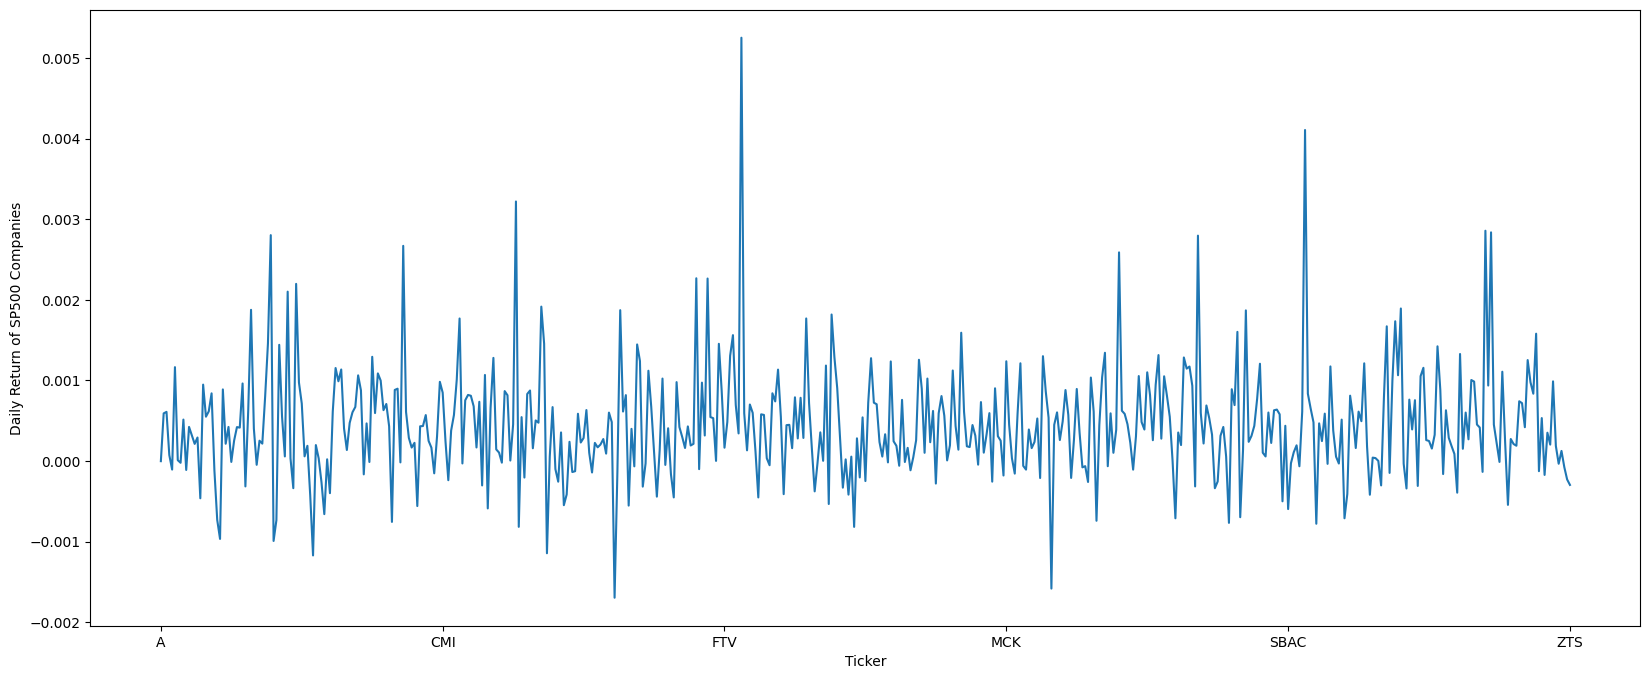

In [18]:
from matplotlib import pyplot as plt
plt.figure(figsize=(20,8))
dr_mean.plot()
plt.ylabel("Daily Return of SP500 Companies")
plt.show()

# ***Beta Calculation:***

In [19]:
def fetch_data(tickers, index='^GSPC', start=None, end=None, interval='1d'):
    all_tickers = tickers + [index]
    df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
    return df

In [20]:
def calculate_ratios(returns, benchmark_returns, risk_free_rate=0.04/252):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]

    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)
    return beta

In [21]:
def build_screener(tickers, index='^GSPC', start=None, end=None, risk_free_rate=0.04/252):
    df = fetch_data(tickers, index=index, start=start, end=end)
    benchmark = df[index].pct_change().dropna()
    results = []

    for ticker in tickers:
        ret = df[ticker].pct_change().dropna()
        aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()
        beta = calculate_ratios(aligned[ticker], aligned[index], risk_free_rate)
        results.append({'Ticker': ticker, 'Beta': beta})

    return pd.DataFrame(results).sort_values('Beta', ascending=False)

In [22]:
import numpy as np
df = build_screener(tickers, index='^GSPC', start=start, end=end)
print(df)

/tmp/ipykernel_610/2721606737.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
/tmp/ipykernel_610/3292031660.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = df[ticker].pct_change().dropna()
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/li

    Ticker      Beta
88    CVNA  3.298454
118   COIN  2.964902
67     XYZ  2.548173
344   NVDA  2.271536
40     APP  2.264945
..     ...       ...
414    SJM  0.196851
83     CPB  0.133843
219    GIS  0.133427
386      Q       NaN
405   SNDK       NaN

[503 rows x 2 columns]


In [23]:
df

,Ticker,Beta
88,CVNA,3.298454
118,COIN,2.964902
67,XYZ,2.548173
344,NVDA,2.271536
40,APP,2.264945
...,...,...
414,SJM,0.196851
83,CPB,0.133843
219,GIS,0.133427
386,Q,NaN


In [24]:
df.dropna()

,Ticker,Beta
88,CVNA,3.298454
118,COIN,2.964902
67,XYZ,2.548173
344,NVDA,2.271536
40,APP,2.264945
...,...,...
292,LMT,0.244189
238,HRL,0.236922
414,SJM,0.196851
83,CPB,0.133843


In [25]:
import statistics
Annual_vol = daily_returns.std() * np.sqrt(252)
Annual_vol.name = 'Annual Volatility'
Annual_vol

,Annual Volatility
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839
...,...
XYZ,0.653825
YUM,0.191335
ZBH,0.245157


In [26]:
all_dim = df.merge(Annual_vol, left_on='Ticker', right_index=True)
all_dim = all_dim.merge(dr_mean, left_on='Ticker', right_index=True)
all_dim

,Ticker,Beta,Annual Volatility,Average Daily returns
88,CVNA,3.298454,1.341039,0.003219
118,COIN,2.964902,0.953848,0.001768
67,XYZ,2.548173,0.653825,-0.000034
344,NVDA,2.271536,0.552710,0.002588
40,APP,2.264945,0.788374,0.002802
...,...,...,...,...
292,LMT,0.244189,0.209530,0.000611
238,HRL,0.236922,0.232603,-0.000376
414,SJM,0.196851,0.219994,-0.000065
83,CPB,0.133843,0.223119,0.000168


In [27]:
all_dim

,Ticker,Beta,Annual Volatility,Average Daily returns
88,CVNA,3.298454,1.341039,0.003219
118,COIN,2.964902,0.953848,0.001768
67,XYZ,2.548173,0.653825,-0.000034
344,NVDA,2.271536,0.552710,0.002588
40,APP,2.264945,0.788374,0.002802
...,...,...,...,...
292,LMT,0.244189,0.209530,0.000611
238,HRL,0.236922,0.232603,-0.000376
414,SJM,0.196851,0.219994,-0.000065
83,CPB,0.133843,0.223119,0.000168


In [28]:
all_dim_100 = all_dim.iloc[:100]

In [29]:
from matplotlib import pyplot as plt
import seaborn as sns

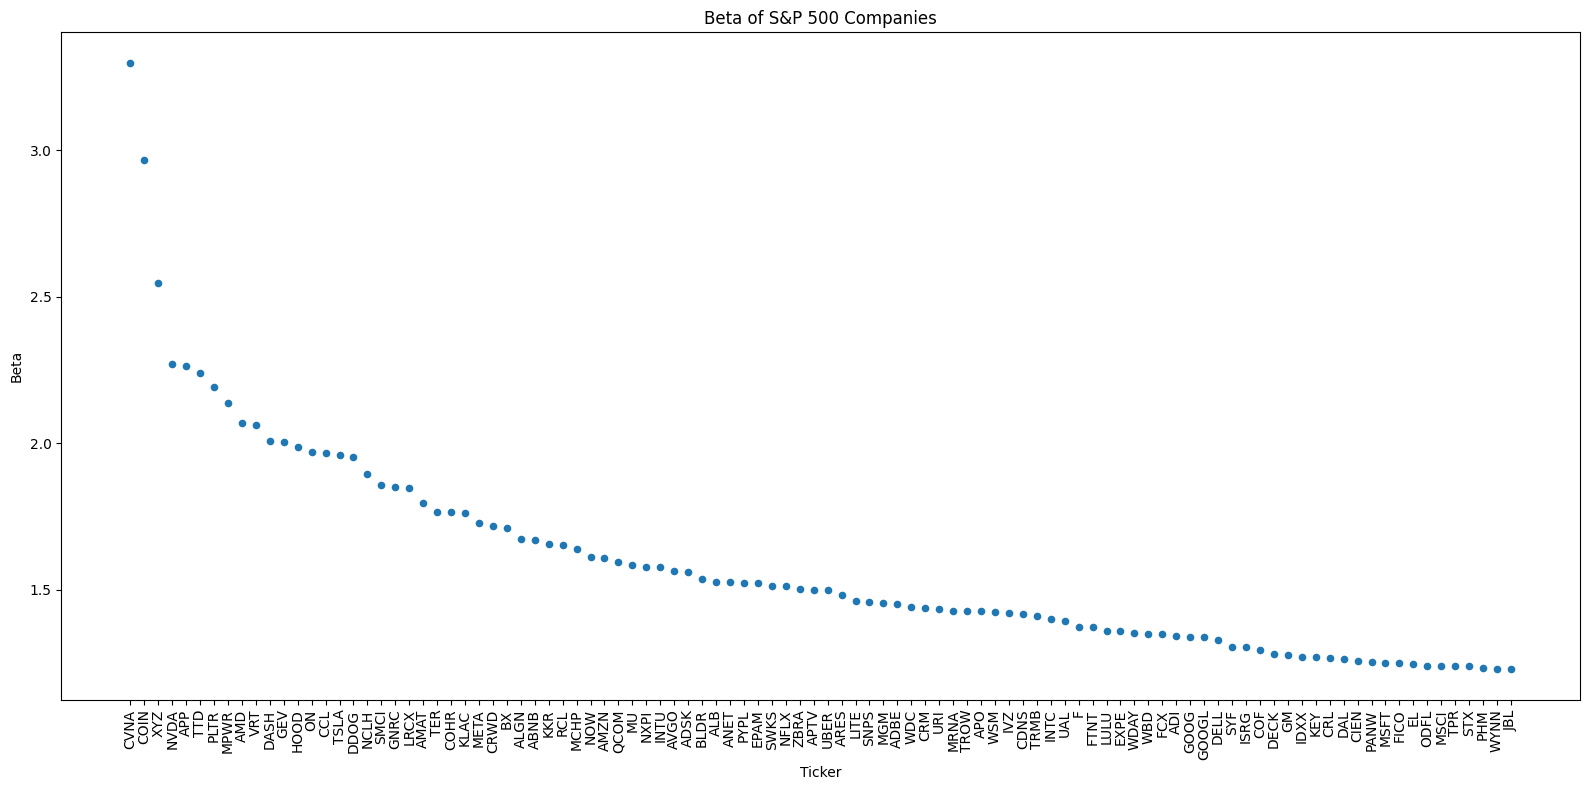

In [30]:
all_dim_100.plot(x='Ticker', y=['Beta'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Beta')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

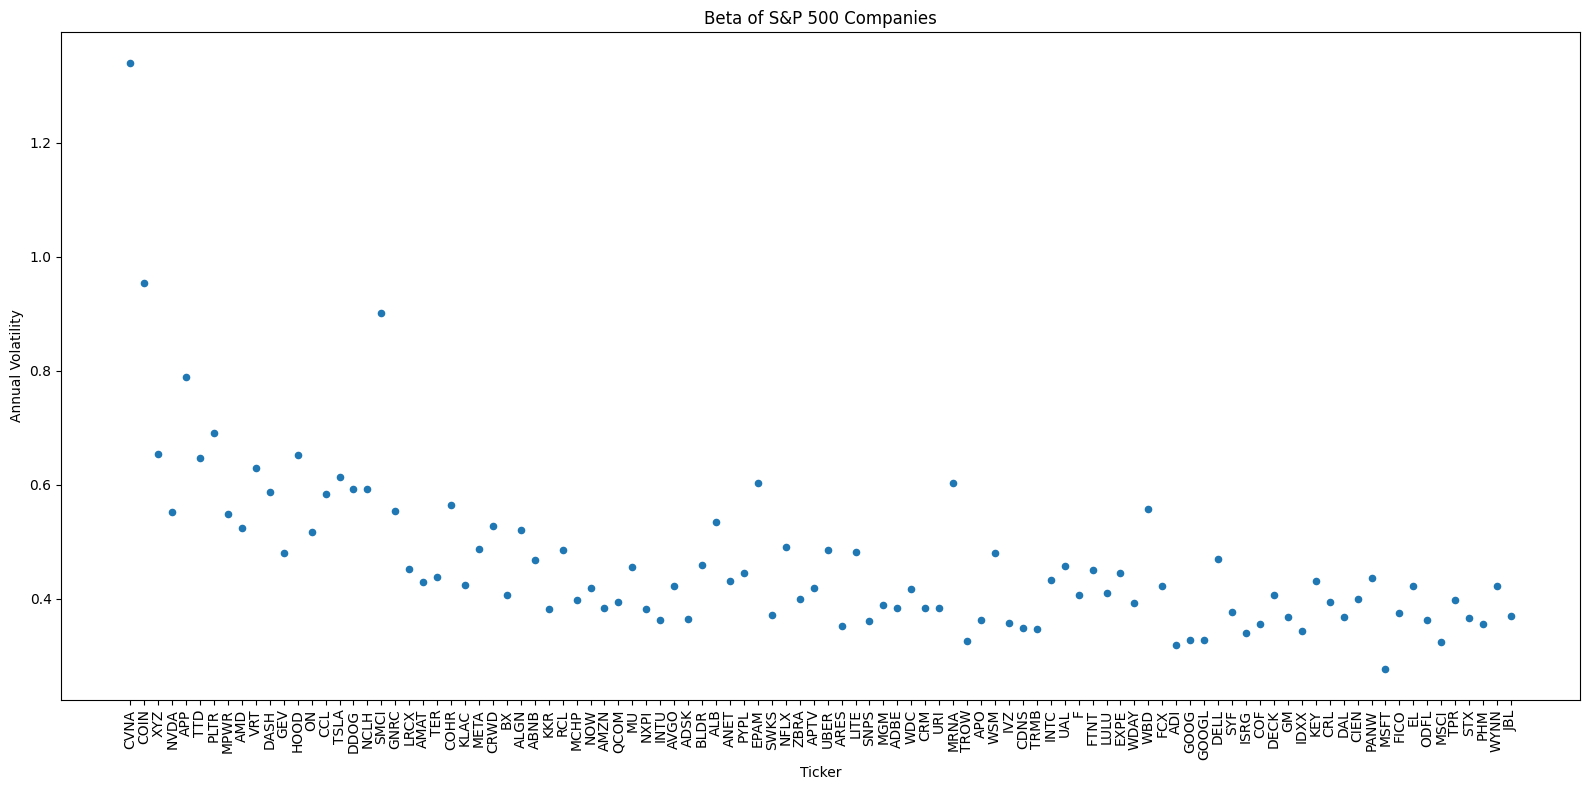

In [31]:
all_dim_100.plot(x='Ticker', y=['Annual Volatility'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Annual Volatility')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

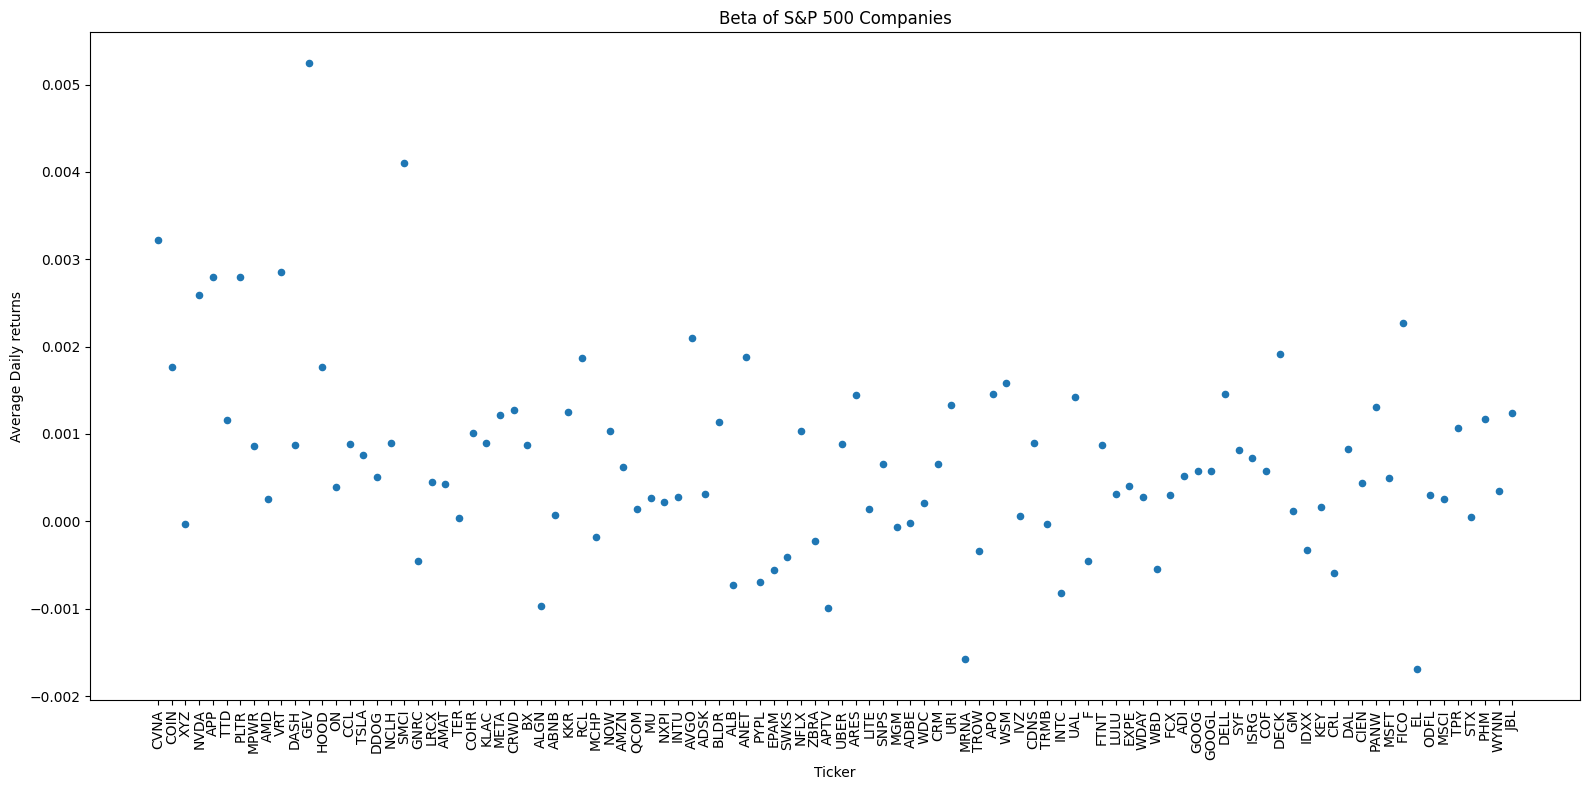

In [32]:
all_dim_100.plot(x='Ticker', y=['Average Daily returns'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Average Daily returns')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## **Part B: Customer Segmentation:**

In [33]:
print(all_dim.index.tolist())
print(all_dim[['Beta', 'Annual Volatility', 'Average Daily returns']].isna().sum())

[88, 118, 67, 344, 40, 446, 357, 321, 6, 472, 157, 215, 397, 351, 86, 439, 143, 341, 426, 217, 284, 39, 438, 117, 279, 310, 136, 66, 15, 11, 278, 402, 314, 410, 22, 384, 315, 346, 258, 73, 50, 77, 13, 45, 362, 176, 413, 330, 500, 41, 456, 44, 296, 428, 313, 5, 490, 404, 462, 318, 431, 37, 492, 260, 81, 451, 253, 460, 204, 205, 295, 189, 495, 483, 210, 34, 20, 19, 147, 427, 259, 84, 145, 220, 248, 273, 98, 148, 105, 358, 316, 195, 183, 349, 327, 433, 408, 382, 496, 265, 359, 252, 387, 55, 121, 209, 38, 274, 371, 178, 65, 150, 262, 287, 453, 30, 291, 398, 63, 223, 343, 440, 251, 160, 87, 422, 111, 420, 312, 33, 241, 335, 436, 135, 360, 288, 200, 70, 132, 92, 383, 380, 363, 26, 234, 423, 239, 323, 452, 212, 193, 4, 102, 128, 240, 285, 449, 130, 302, 165, 324, 69, 62, 300, 164, 498, 393, 303, 489, 339, 79, 201, 235, 329, 225, 396, 244, 93, 332, 269, 442, 206, 482, 333, 213, 9, 345, 388, 377, 372, 448, 126, 7, 477, 110, 199, 435, 226, 353, 476, 14, 370, 163, 421, 485, 16, 412, 455, 167, 214

In [34]:
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform(all_dim[['Beta', 'Annual Volatility', 'Average Daily returns']])
scaled_df = pd.DataFrame(scaled, columns=['Beta', 'Annual Volatility', 'Average Daily returns'], index=all_dim.index)
all_dim_scaled = all_dim.copy()
all_dim_scaled[['Beta', 'Annual Volatility', 'Average Daily returns']] = scaled_df
all_dim_scaled

,Ticker,Beta,Annual Volatility,Average Daily returns
88,CVNA,5.428836,8.970879,3.968741
118,COIN,4.659422,5.587688,1.890354
67,XYZ,3.698144,2.966157,-0.690010
344,NVDA,3.060020,2.082636,3.064849
40,APP,3.044815,4.141821,3.370873
...,...,...,...,...
292,LMT,-1.616509,-0.915995,0.233328
238,HRL,-1.633272,-0.714384,-1.180191
414,SJM,-1.725705,-0.824561,-0.734598
83,CPB,-1.871048,-0.797257,-0.400659


In [35]:
print(scaled_df.index.tolist())
print(scaled_df.isna().sum())

[88, 118, 67, 344, 40, 446, 357, 321, 6, 472, 157, 215, 397, 351, 86, 439, 143, 341, 426, 217, 284, 39, 438, 117, 279, 310, 136, 66, 15, 11, 278, 402, 314, 410, 22, 384, 315, 346, 258, 73, 50, 77, 13, 45, 362, 176, 413, 330, 500, 41, 456, 44, 296, 428, 313, 5, 490, 404, 462, 318, 431, 37, 492, 260, 81, 451, 253, 460, 204, 205, 295, 189, 495, 483, 210, 34, 20, 19, 147, 427, 259, 84, 145, 220, 248, 273, 98, 148, 105, 358, 316, 195, 183, 349, 327, 433, 408, 382, 496, 265, 359, 252, 387, 55, 121, 209, 38, 274, 371, 178, 65, 150, 262, 287, 453, 30, 291, 398, 63, 223, 343, 440, 251, 160, 87, 422, 111, 420, 312, 33, 241, 335, 436, 135, 360, 288, 200, 70, 132, 92, 383, 380, 363, 26, 234, 423, 239, 323, 452, 212, 193, 4, 102, 128, 240, 285, 449, 130, 302, 165, 324, 69, 62, 300, 164, 498, 393, 303, 489, 339, 79, 201, 235, 329, 225, 396, 244, 93, 332, 269, 442, 206, 482, 333, 213, 9, 345, 388, 377, 372, 448, 126, 7, 477, 110, 199, 435, 226, 353, 476, 14, 370, 163, 421, 485, 16, 412, 455, 167, 214

In [36]:
print(all_dim_scaled.index.tolist())
print(all_dim_scaled.isna().sum())

[88, 118, 67, 344, 40, 446, 357, 321, 6, 472, 157, 215, 397, 351, 86, 439, 143, 341, 426, 217, 284, 39, 438, 117, 279, 310, 136, 66, 15, 11, 278, 402, 314, 410, 22, 384, 315, 346, 258, 73, 50, 77, 13, 45, 362, 176, 413, 330, 500, 41, 456, 44, 296, 428, 313, 5, 490, 404, 462, 318, 431, 37, 492, 260, 81, 451, 253, 460, 204, 205, 295, 189, 495, 483, 210, 34, 20, 19, 147, 427, 259, 84, 145, 220, 248, 273, 98, 148, 105, 358, 316, 195, 183, 349, 327, 433, 408, 382, 496, 265, 359, 252, 387, 55, 121, 209, 38, 274, 371, 178, 65, 150, 262, 287, 453, 30, 291, 398, 63, 223, 343, 440, 251, 160, 87, 422, 111, 420, 312, 33, 241, 335, 436, 135, 360, 288, 200, 70, 132, 92, 383, 380, 363, 26, 234, 423, 239, 323, 452, 212, 193, 4, 102, 128, 240, 285, 449, 130, 302, 165, 324, 69, 62, 300, 164, 498, 393, 303, 489, 339, 79, 201, 235, 329, 225, 396, 244, 93, 332, 269, 442, 206, 482, 333, 213, 9, 345, 388, 377, 372, 448, 126, 7, 477, 110, 199, 435, 226, 353, 476, 14, 370, 163, 421, 485, 16, 412, 455, 167, 214

In [37]:
print(all_dim_scaled[all_dim_scaled['Ticker'].isin(['ZBH', 'ZTS'])])

    Ticker      Beta  Annual Volatility  Average Daily returns
502    ZTS -0.062605          -0.343793              -1.065902
501    ZBH -0.478615          -0.604693              -0.750103


In [38]:
print(all_dim_scaled[all_dim_scaled.isna().any(axis=1)])

Empty DataFrame
Columns: [Ticker, Beta, Annual Volatility, Average Daily returns]
Index: []


<function matplotlib.pyplot.show(close=None, block=None)>

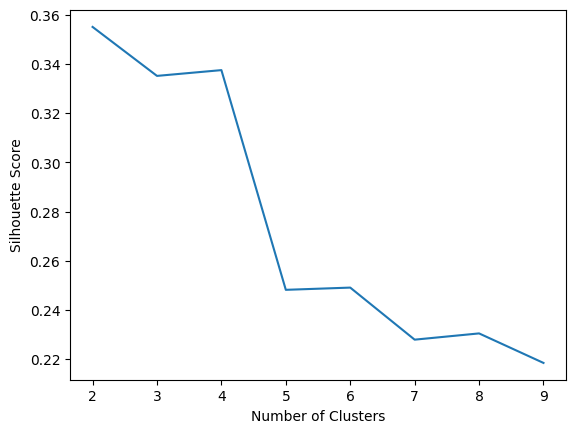

In [39]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
#assigning Beta column to X
X = all_dim_scaled[['Beta', 'Annual Volatility', 'Average Daily returns']]
#testing number of cluster from 2 to 10 and collecting the silhouette
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for n_clusters in range_n_clusters:
  agglom = AgglomerativeClustering(n_clusters=n_clusters)
  agglom.fit(X)

  labels = agglom.labels_
  scores.append(silhouette_score(X, labels))
#looking at the scores, and their average/mean
scores
average = sum(scores)/len(scores)
average
#graphing
plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show

Cluster 1 has 179 observations
Cluster 2 has 322 observations


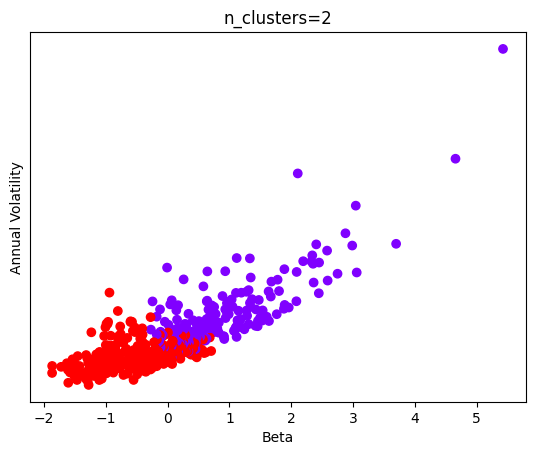

Cluster 1 has 160 observations
Cluster 2 has 322 observations
Cluster 3 has 19 observations


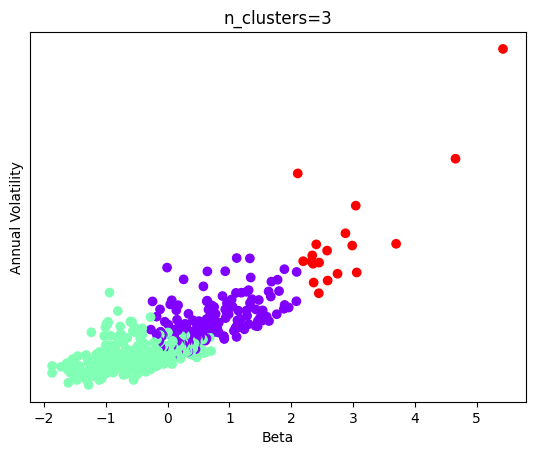

Cluster 1 has 322 observations
Cluster 2 has 95 observations
Cluster 3 has 19 observations
Cluster 4 has 65 observations


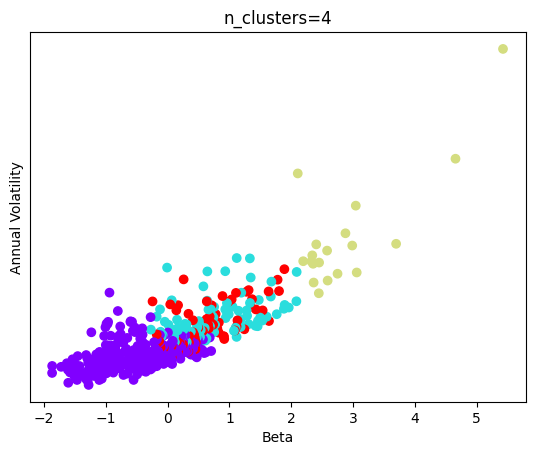

Cluster 1 has 19 observations
Cluster 2 has 95 observations
Cluster 3 has 213 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations


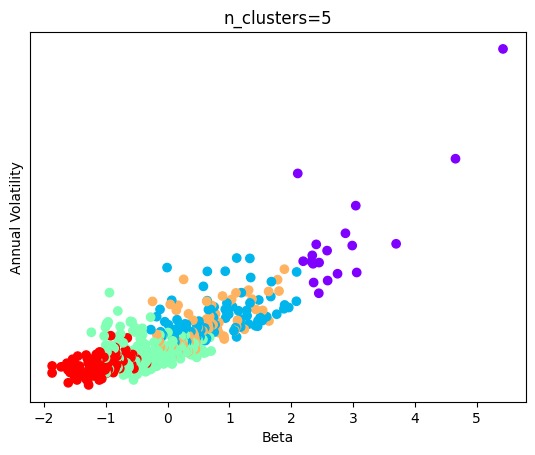

Cluster 1 has 213 observations
Cluster 2 has 95 observations
Cluster 3 has 8 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations


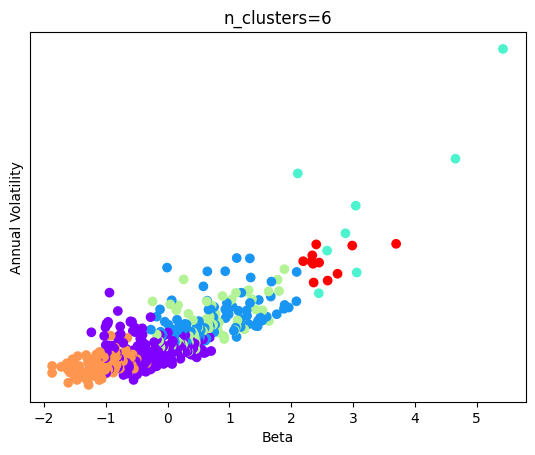

Cluster 1 has 8 observations
Cluster 2 has 95 observations
Cluster 3 has 113 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations


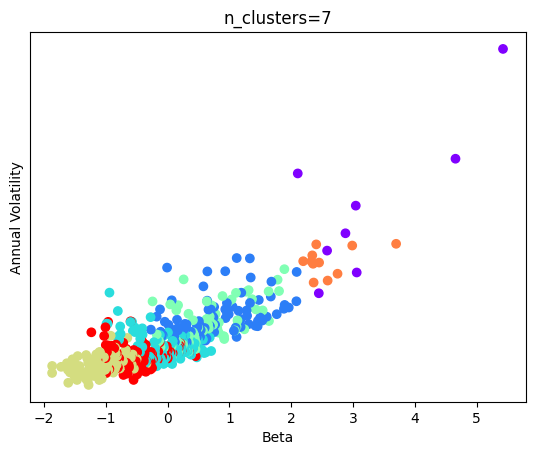

Cluster 1 has 95 observations
Cluster 2 has 65 observations
Cluster 3 has 113 observations
Cluster 4 has 6 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations
Cluster 8 has 2 observations


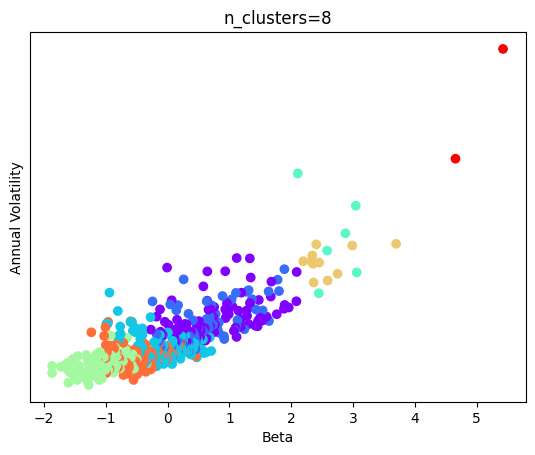

Cluster 1 has 65 observations
Cluster 2 has 109 observations
Cluster 3 has 113 observations
Cluster 4 has 6 observations
Cluster 5 has 50 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations
Cluster 8 has 2 observations
Cluster 9 has 45 observations


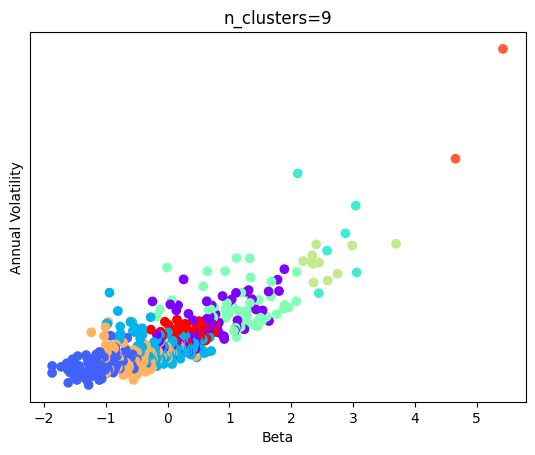

In [40]:
for n_clusters in range_n_clusters:
  model = AgglomerativeClustering(n_clusters=n_clusters)
  labels = model.fit_predict(X)
  plt.scatter(all_dim_scaled['Beta'], all_dim_scaled['Annual Volatility'], c=labels, cmap='rainbow')
  plt.xlabel('Beta')
  plt.ylabel('Annual Volatility')
  plt.title(f"n_clusters={n_clusters}")
  cluster_counts = np.bincount(labels)
  for i in range(n_clusters):
    print(f"Cluster {i+1} has {cluster_counts[i]} observations")
  plt.yticks([])
  plt.show()

Cluster 1 has 179 observations
Cluster 2 has 322 observations


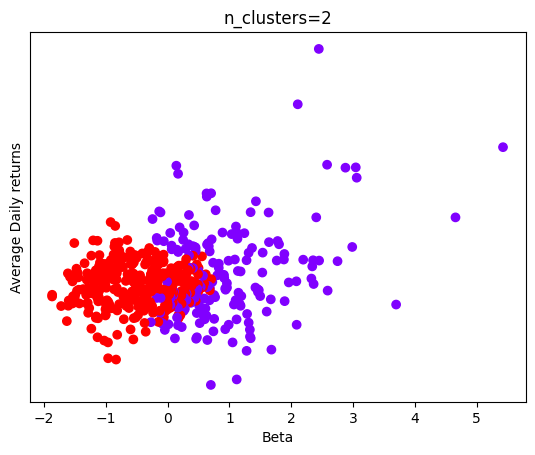

Cluster 1 has 160 observations
Cluster 2 has 322 observations
Cluster 3 has 19 observations


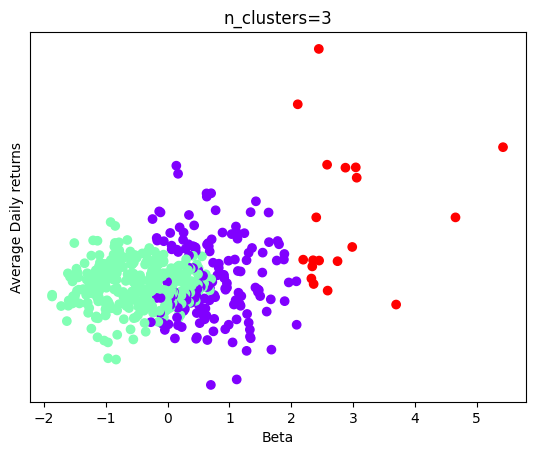

Cluster 1 has 322 observations
Cluster 2 has 95 observations
Cluster 3 has 19 observations
Cluster 4 has 65 observations


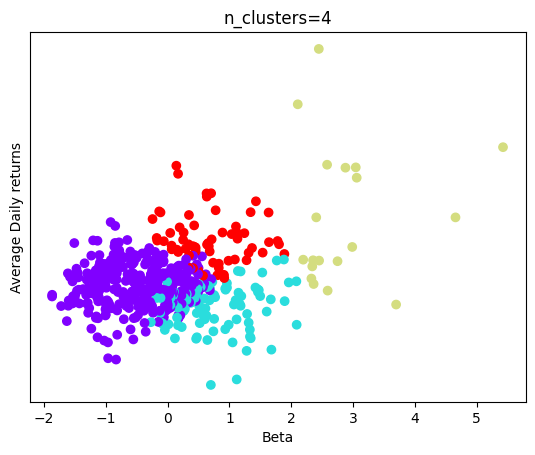

Cluster 1 has 19 observations
Cluster 2 has 95 observations
Cluster 3 has 213 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations


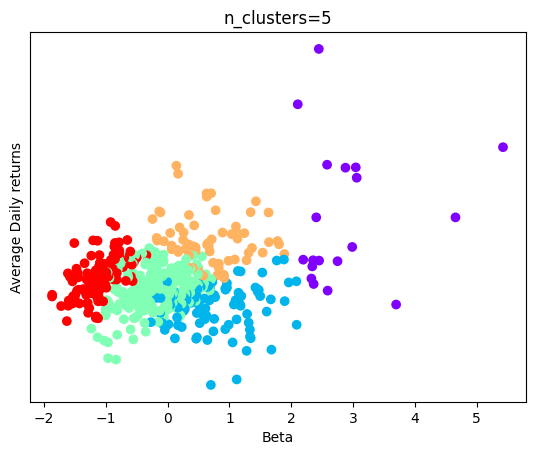

Cluster 1 has 213 observations
Cluster 2 has 95 observations
Cluster 3 has 8 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations


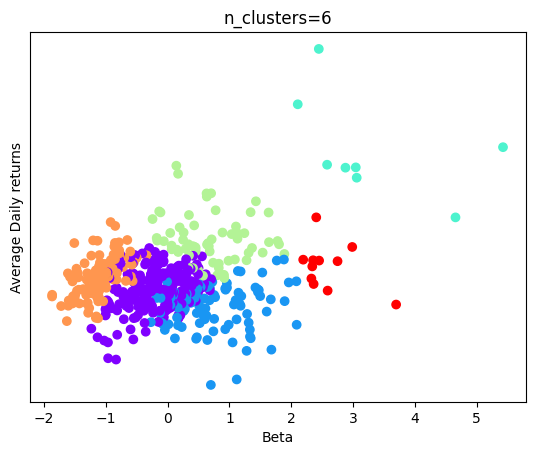

Cluster 1 has 8 observations
Cluster 2 has 95 observations
Cluster 3 has 113 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations


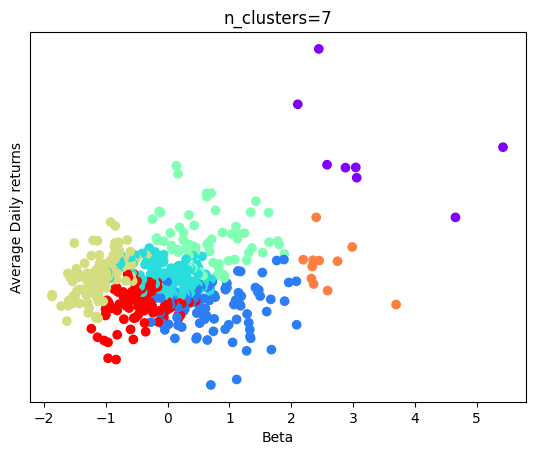

Cluster 1 has 95 observations
Cluster 2 has 65 observations
Cluster 3 has 113 observations
Cluster 4 has 6 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations
Cluster 8 has 2 observations


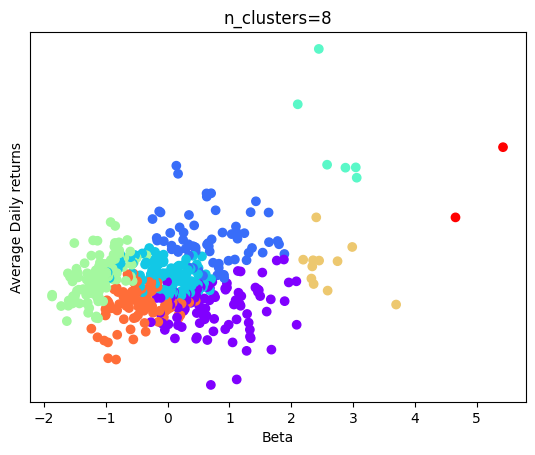

Cluster 1 has 65 observations
Cluster 2 has 109 observations
Cluster 3 has 113 observations
Cluster 4 has 6 observations
Cluster 5 has 50 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations
Cluster 8 has 2 observations
Cluster 9 has 45 observations


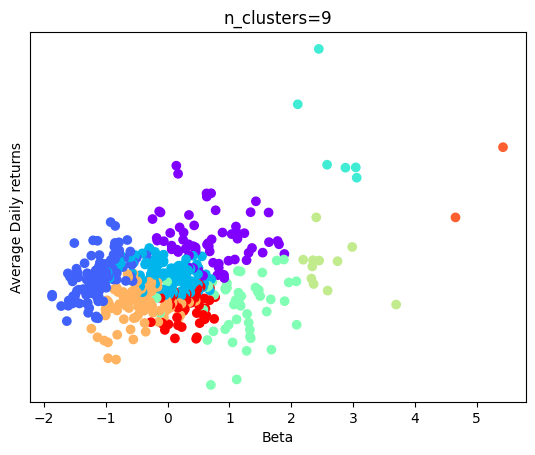

In [41]:
for n_clusters in range_n_clusters:
  model = AgglomerativeClustering(n_clusters=n_clusters)
  labels = model.fit_predict(X)
  plt.scatter(all_dim_scaled['Beta'], all_dim_scaled['Average Daily returns'], c=labels, cmap='rainbow')
  plt.xlabel('Beta')
  plt.ylabel('Average Daily returns')
  plt.title(f"n_clusters={n_clusters}")
  cluster_counts = np.bincount(labels)
  for i in range(n_clusters):
    print(f"Cluster {i+1} has {cluster_counts[i]} observations")
  plt.yticks([])
  plt.show()

Cluster 1 has 179 observations
Cluster 2 has 322 observations


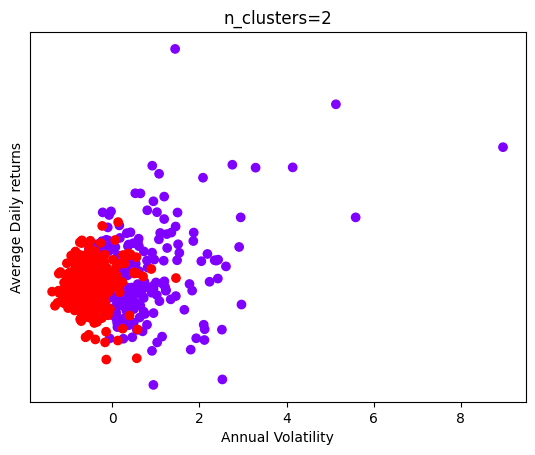

Cluster 1 has 160 observations
Cluster 2 has 322 observations
Cluster 3 has 19 observations


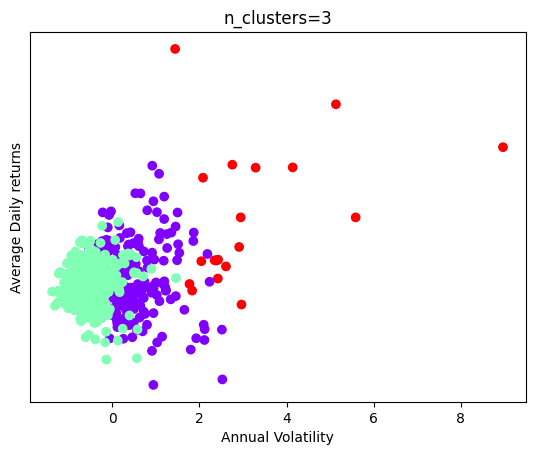

Cluster 1 has 322 observations
Cluster 2 has 95 observations
Cluster 3 has 19 observations
Cluster 4 has 65 observations


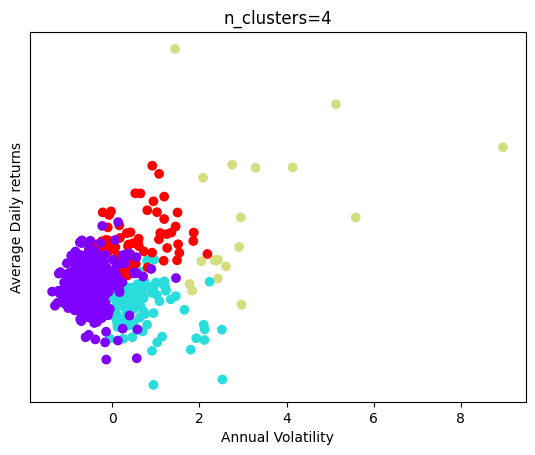

Cluster 1 has 19 observations
Cluster 2 has 95 observations
Cluster 3 has 213 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations


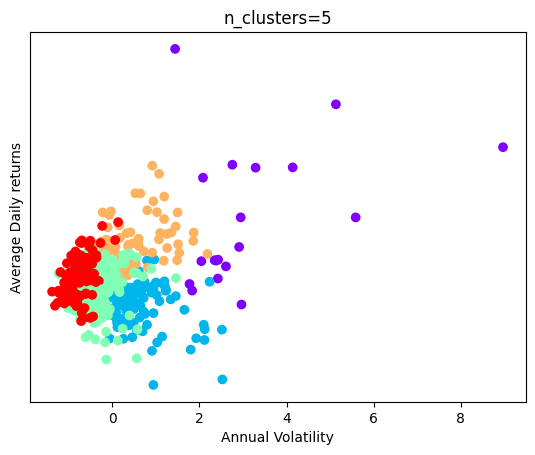

Cluster 1 has 213 observations
Cluster 2 has 95 observations
Cluster 3 has 8 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations


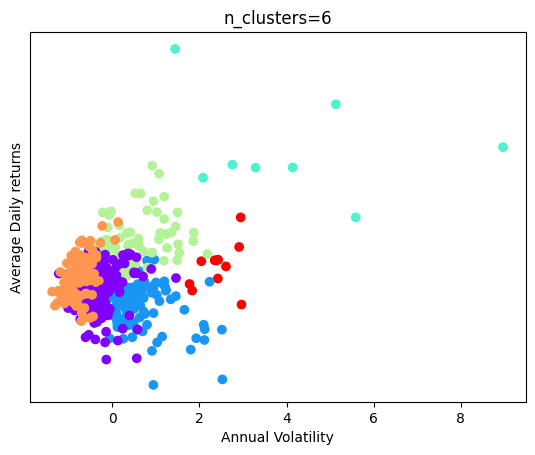

Cluster 1 has 8 observations
Cluster 2 has 95 observations
Cluster 3 has 113 observations
Cluster 4 has 65 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations


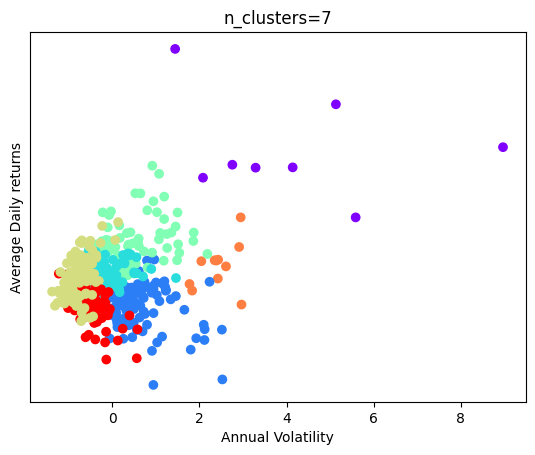

Cluster 1 has 95 observations
Cluster 2 has 65 observations
Cluster 3 has 113 observations
Cluster 4 has 6 observations
Cluster 5 has 109 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations
Cluster 8 has 2 observations


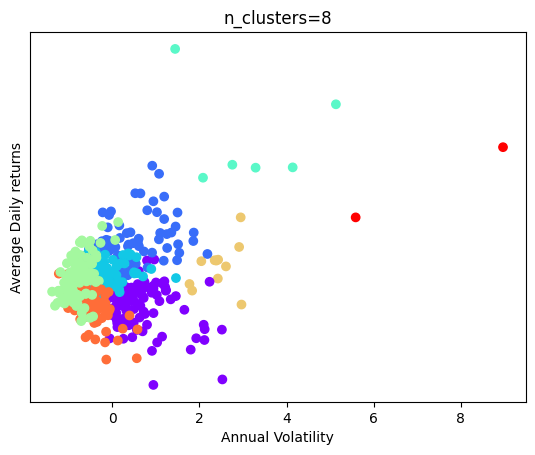

Cluster 1 has 65 observations
Cluster 2 has 109 observations
Cluster 3 has 113 observations
Cluster 4 has 6 observations
Cluster 5 has 50 observations
Cluster 6 has 11 observations
Cluster 7 has 100 observations
Cluster 8 has 2 observations
Cluster 9 has 45 observations


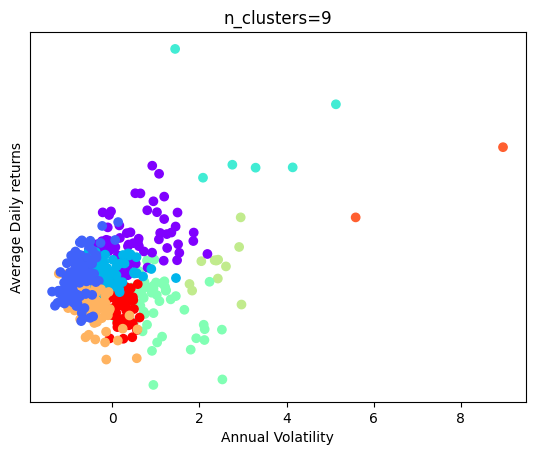

In [42]:
for n_clusters in range_n_clusters:
  model = AgglomerativeClustering(n_clusters=n_clusters)
  labels = model.fit_predict(X)
  plt.scatter(all_dim_scaled['Annual Volatility'], all_dim_scaled['Average Daily returns'], c=labels, cmap='rainbow')
  plt.xlabel('Annual Volatility')
  plt.ylabel('Average Daily returns')
  plt.title(f"n_clusters={n_clusters}")
  cluster_counts = np.bincount(labels)
  for i in range(n_clusters):
    print(f"Cluster {i+1} has {cluster_counts[i]} observations")
  plt.yticks([])
  plt.show()

In [43]:
optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
cluster_labels = agglom.fit_predict(all_dim_scaled[['Beta','Annual Volatility', 'Average Daily returns']])
all_dim_scaled['Cluster'] = cluster_labels
all_dim_scaled

,Ticker,Beta,Annual Volatility,Average Daily returns,Cluster
88,CVNA,5.428836,8.970879,3.968741,0
118,COIN,4.659422,5.587688,1.890354,0
67,XYZ,3.698144,2.966157,-0.690010,0
344,NVDA,3.060020,2.082636,3.064849,0
40,APP,3.044815,4.141821,3.370873,0
...,...,...,...,...,...
292,LMT,-1.616509,-0.915995,0.233328,4
238,HRL,-1.633272,-0.714384,-1.180191,4
414,SJM,-1.725705,-0.824561,-0.734598,4
83,CPB,-1.871048,-0.797257,-0.400659,4


/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


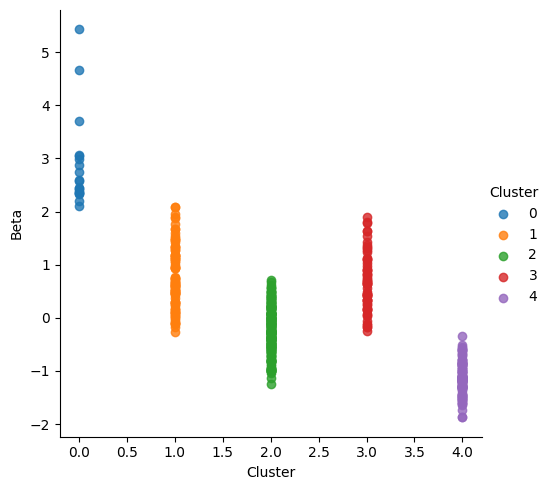

In [44]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='Cluster', y='Beta', hue='Cluster',
legend=True, legend_out=True);

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


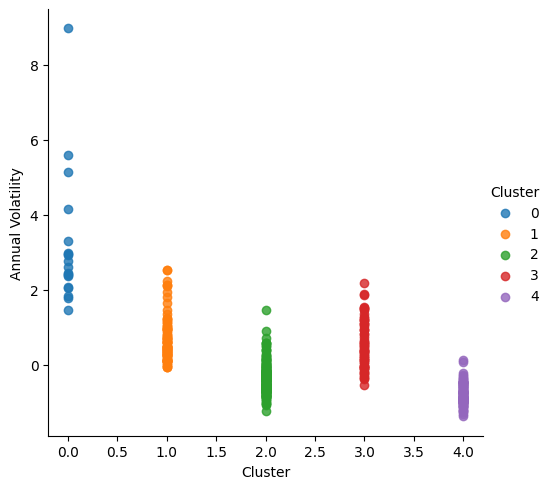

In [45]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='Cluster', y='Annual Volatility', hue='Cluster',
legend=True, legend_out=True);

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


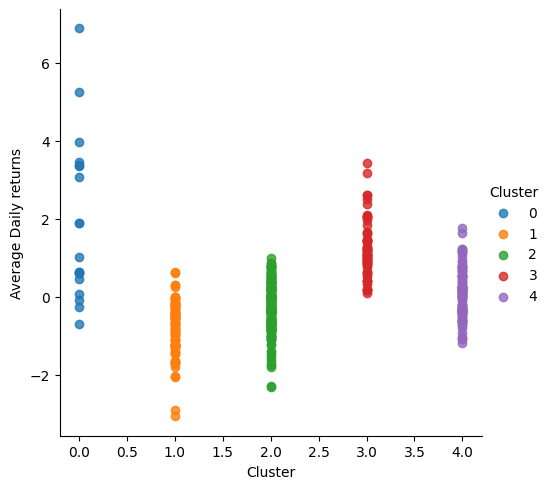

In [46]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='Cluster', y='Average Daily returns', hue='Cluster',
legend=True, legend_out=True);

<function matplotlib.pyplot.show(close=None, block=None)>

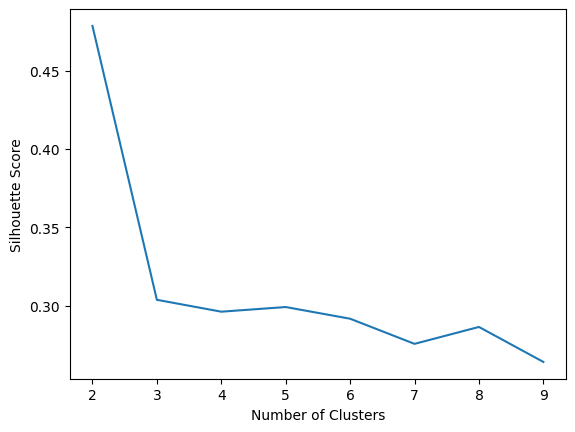

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
#assigning Beta column to X
X = all_dim_scaled[['Beta', 'Annual Volatility', 'Average Daily returns']]
#testing number of cluster from 2 to 10 and collecting the silhouette
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for n_clusters in range_n_clusters:
  km = KMeans(n_clusters=n_clusters)
  km.fit(X)

  labels = km.labels_
  scores.append(silhouette_score(X, labels))
#looking at the scores, and their average/mean
scores
average = sum(scores)/len(scores)
average
#graphing
plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, max_iter=1000)
kmeans_labels = kmeans.fit_predict(all_dim_scaled[['Beta', 'Annual Volatility', 'Average Daily returns']])
all_dim_scaled['KMeans_Cluster'] = kmeans_labels
all_dim_scaled

,Ticker,Beta,Annual Volatility,Average Daily returns,Cluster,KMeans_Cluster
88,CVNA,5.428836,8.970879,3.968741,0,1
118,COIN,4.659422,5.587688,1.890354,0,1
67,XYZ,3.698144,2.966157,-0.690010,0,1
344,NVDA,3.060020,2.082636,3.064849,0,1
40,APP,3.044815,4.141821,3.370873,0,1
...,...,...,...,...,...,...
292,LMT,-1.616509,-0.915995,0.233328,4,2
238,HRL,-1.633272,-0.714384,-1.180191,4,2
414,SJM,-1.725705,-0.824561,-0.734598,4,2
83,CPB,-1.871048,-0.797257,-0.400659,4,2


/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


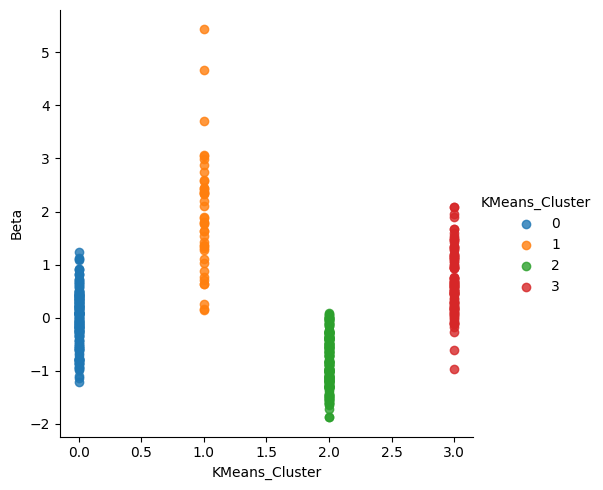

In [49]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='KMeans_Cluster', y='Beta', hue='KMeans_Cluster',
legend=True, legend_out=True);


/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


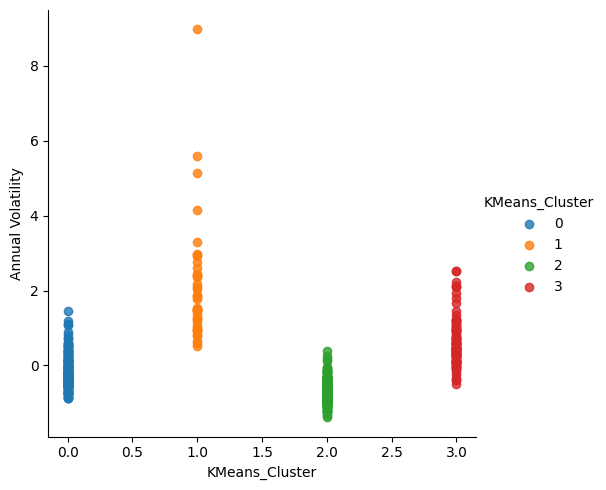

In [50]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='KMeans_Cluster', y='Annual Volatility', hue='KMeans_Cluster',
legend=True, legend_out=True);

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


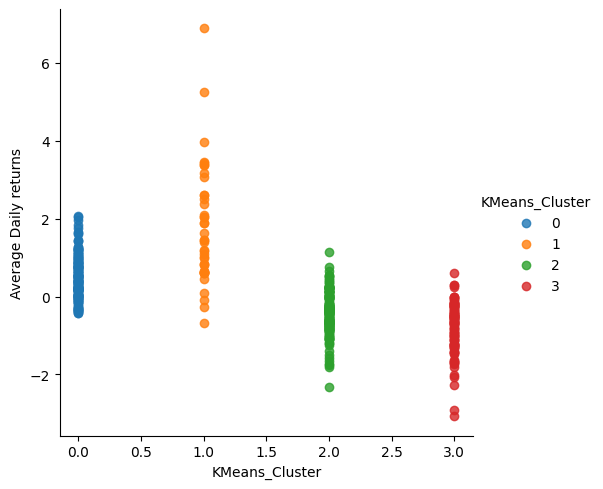

In [51]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='KMeans_Cluster', y='Average Daily returns', hue='KMeans_Cluster',
legend=True, legend_out=True);